# ILCS 2015: Correlation matrix and column removal

## Goal

Load the **imputed** household data (KNN k=9 from the main pipeline), compute the **correlation matrix** (Pearson, numeric columns only; **tsne_1**, **tsne_2**, **cluster** are excluded so we don't drop survey variables just because they correlate with the embedding), identify **redundant** pairs (|r| > 0.7), and drop columns that are either redundant or **not** poverty/socioeconomic. Save the **final** dataset and a **detailed removal log** (which columns were removed and why).

## 1. Load imputed data

**Input:** `ml_households_imputed_k9.csv` (produced by the main t-SNE notebook).

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
IMPUTED_CSV = DATA_DIR / "imputed" / "ml_households_imputed_k9.csv"
FINAL_CSV = DATA_DIR / "final_dropped" / "ml_households_final_dropped.csv"
REMOVAL_LOG_CSV = DATA_DIR / "final_dropped" / "columns_removal_log.csv"
REMOVAL_LOG_MD = DATA_DIR / "final_dropped" / "columns_removal_log.md"

df = pd.read_csv(IMPUTED_CSV, low_memory=False)
print(f"Imputed data: {df.shape[0]:,} rows, {df.shape[1]} columns")

Imputed data: 5,184 rows, 93 columns


## 2. Curated poverty/socioeconomic columns

We use the same column groups as the main notebook to define which columns are **kept for analysis**. Any column not in this list will be marked for removal as "not poverty/socioeconomic" (unless already removed as redundant).

In [13]:
COLUMNS_EXCLUDE_CORR = ["recno", "date", "weight", "sample_weight", "year", "tsne_1", "tsne_2", "cluster"]  # IDs, weights, and derived (t-SNE/cluster) — exclude so we don't drop survey vars just because they correlate with embedding

COLUMN_GROUPS = {
    "Income & consumption": [
        "household_income_total", "food_purchases_total", "services_goods_total", "goods_services_total",
        "drm_in_amd", "drm_in_amd_2", "money_family_need_monthly_live", "money_family_need_monthly_make", "amd_3",
        "heating_spend_last_winter_amd",
    ],
    "Assets": [
        "household_has_car", "has_computer", "has_internet", "has_mobile", "has_telephone", "has_radio", "has_electricity",
        "dwelling_ownership", "number_of_rooms", "dwelling_space_sqm", "has_other_dwelling",
    ],
    "Housing quality": [
        "dwelling_condition_estimate", "has_centralized_water", "has_hot_water", "has_centralized_sanitation", "has_local_sanitation", "has_outside_toilet", "has_gas", "has_bathtub_shower", "has_kitchen",
        "main_heating_energy", "garbage_disposal",
        "complaint_floor_space", "complaint_noise", "complaint_light", "complaint_heating", "complaint_humidity", "complaint_leaking_roof", "complaint_walls_floor", "complaint_windows_doors", "complaint_traffic", "complaint_pollution", "complaint_elevator", "complaint_water_supply", "complaint_garbage", "complaint_common_areas", "complaint_green_areas", "complaint_other",
    ],
    "Household structure": [
        "household_size", "household_member_count", "household_mean_age", "household_has_special_education_children",
    ],
    "Vulnerability & benefits": [
        "registered_poverty_benefit", "share_families_really_vulnerable", "humanitarian_assistance_12m", "benefit_system_justified",
    ],
    "Debt & transfers": [
        "family_debt_amount", "borrowed_money_12m", "household_sent_money_goods_12m", "household_received_money_goods_12m", "lent_money_12m",
    ],
    "Economic activity": [
        "any_member_household_own_work", "household_income_source_count", "engaged_cattle_breeding", "hired_household_workers_12m", "eligible_salary_pension_not_received",
    ],
    "Dwelling & other": [
        "dwelling_renovated", "building_new_house", "housing_type",
        "water_source", "potable_water_hours_day", "potable_water_24h",
        "food_which_usually_consumed_daily", "food_which_usually_consumed_daily_2", "food_which_usually_consumed_daily_3", "food_which_usually_consumed_daily_5", "food_which_usually_consumed_daily_8",
    ],
}

feature_cols = []
for cols in COLUMN_GROUPS.values():
    kept = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    feature_cols.extend(kept)
POVERTY_SET = set(feature_cols)
print(f"Curated poverty/socioeconomic columns: {len(feature_cols)}")

Curated poverty/socioeconomic columns: 77


## 3. Correlation matrix (numeric only; exclude IDs/weights)

We compute Pearson correlation on **numeric** columns only. Columns in `COLUMNS_EXCLUDE_CORR` (recno, date, weight, sample_weight, year) are excluded from the matrix.

In [14]:
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
cols_for_corr = [c for c in numeric_cols if c not in COLUMNS_EXCLUDE_CORR]
corr_matrix = df[cols_for_corr].corr(method="pearson")
print(f"Correlation matrix: {corr_matrix.shape[0]} x {corr_matrix.shape[1]} columns")

Correlation matrix: 83 x 83 columns


## 4. Heatmap of correlation matrix

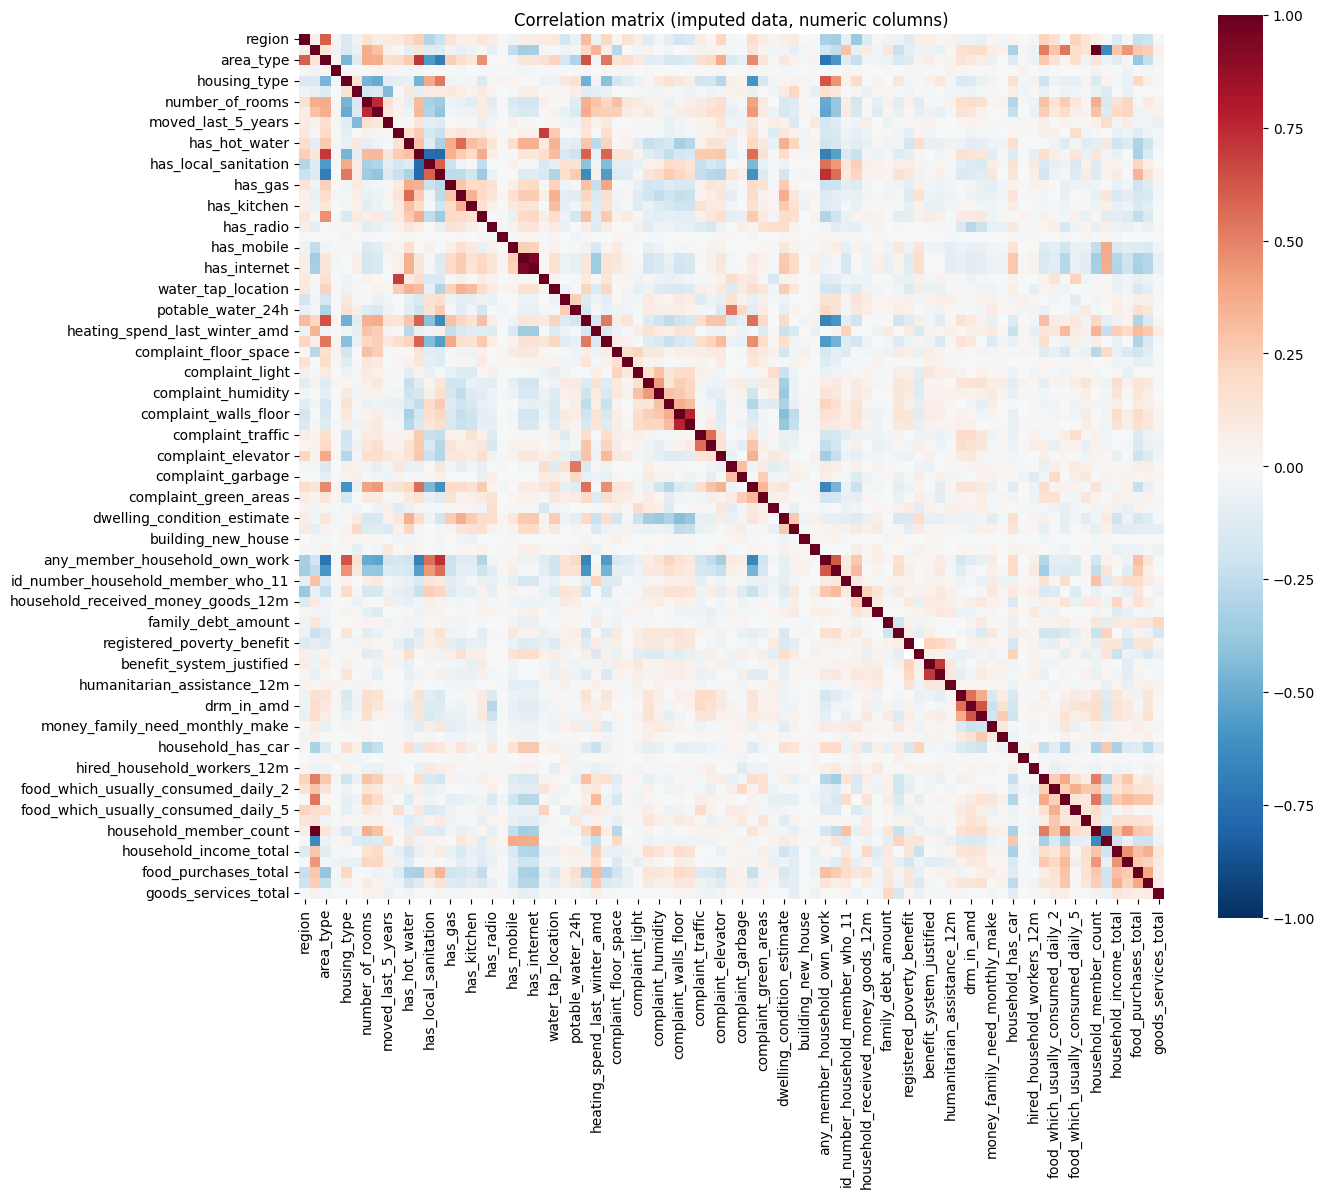

In [15]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlation matrix (imputed data, numeric columns)")
plt.tight_layout()
plt.show()

## 5. Identify pairs with |correlation| > 0.7

For each pair we **drop one** column. **Rule:** keep the column that appears **first** in the curated `feature_cols` order (prioritizes income/consumption and core welfare variables); drop the other.

In [16]:
THRESHOLD = 0.6
high_corr_pairs = []
for i in range(len(cols_for_corr)):
    for j in range(i + 1, len(cols_for_corr)):
        c1, c2 = cols_for_corr[i], cols_for_corr[j]
        r = corr_matrix.loc[c1, c2]
        if abs(r) > THRESHOLD:
            high_corr_pairs.append((c1, c2, r))

print(f"Pairs with |r| > {THRESHOLD}: {len(high_corr_pairs)}")
for c1, c2, r in high_corr_pairs:
    print(f"  {c1} <-> {c2}: r = {r:.3f}")

Pairs with |r| > 0.6: 23
  household_size <-> household_member_count: r = 1.000
  household_size <-> household_mean_age: r = -0.637
  area_type <-> has_centralized_sanitation: r = 0.709
  area_type <-> has_outside_toilet: r = -0.693
  area_type <-> main_heating_energy: r = 0.636
  area_type <-> any_member_household_own_work: r = -0.731
  housing_type <-> any_member_household_own_work: r = 0.626
  number_of_rooms <-> dwelling_space_sqm: r = 0.746
  has_centralized_water <-> water_source: r = 0.695
  has_centralized_sanitation <-> has_local_sanitation: r = -0.771
  has_centralized_sanitation <-> has_outside_toilet: r = -0.782
  has_centralized_sanitation <-> any_member_household_own_work: r = -0.679
  has_outside_toilet <-> main_heating_energy: r = -0.629
  has_outside_toilet <-> complaint_common_areas: r = -0.606
  has_outside_toilet <-> any_member_household_own_work: r = 0.729
  has_computer <-> has_internet: r = 0.945
  main_heating_energy <-> any_member_household_own_work: r = -0.661

In [17]:
# Decide which column to DROP in each pair: drop the one that comes LATER in feature_cols (keep the one more "primary")
order = {c: i for i, c in enumerate(feature_cols)}
for c in cols_for_corr:
    if c not in order:
        order[c] = len(order)  # not in poverty list -> later

to_drop_redundant = set()
for c1, c2, r in high_corr_pairs:
    drop = c2 if order.get(c1, 999) <= order.get(c2, 999) else c1
    to_drop_redundant.add(drop)

print("Columns to drop (redundant, one per pair):", sorted(to_drop_redundant))

Columns to drop (redundant, one per pair): ['any_member_household_own_work', 'area_type', 'benefit_system_justified', 'complaint_common_areas', 'complaint_windows_doors', 'drm_in_amd_2', 'dwelling_space_sqm', 'engaged_cattle_breeding', 'has_internet', 'has_local_sanitation', 'has_outside_toilet', 'household_mean_age', 'household_member_count', 'housing_type', 'main_heating_energy', 'water_source']


## 6. Build removal list and detailed log

- **Redundant:** one from each pair with |r| > 0.7 (already decided above). **tsne_1**, **tsne_2**, **cluster** are excluded from the correlation matrix so they don't create spurious drop decisions.
- **Not poverty/socioeconomic:** any column in the imputed data that is not in the curated `feature_cols` and is not a design/ID column we already exclude (e.g. region, area_type, tsne_1, tsne_2, cluster, labels). We remove only columns that are **numeric and in the correlation matrix** but not in the poverty list. For the removal log we list: (1) each redundant column with reason "Correlation > 0.7 with X"; (2) each column not in poverty list with reason "Not poverty/socioeconomic".

In [18]:
# Columns to remove: (1) redundant (one per high-corr pair), (2) not in poverty/socioeconomic list
removal_log = []  # list of (column_removed, reason, optional_notes)

for c1, c2, r in high_corr_pairs:
    drop = c2 if order.get(c1, 999) <= order.get(c2, 999) else c1
    keep = c1 if drop == c2 else c2
    removal_log.append((drop, f"Correlation > {THRESHOLD} with {keep}", f"r = {r:.3f}"))

not_poverty = [c for c in cols_for_corr if c not in POVERTY_SET]
for c in not_poverty:
    if c not in to_drop_redundant:  # avoid duplicate: only add if not already removed as redundant
        removal_log.append((c, "Not poverty/socioeconomic", ""))

columns_to_remove = to_drop_redundant | set(not_poverty)
print(f"Total columns to remove: {len(columns_to_remove)}")
print(f"  Redundant (corr > {THRESHOLD}): {len(to_drop_redundant)}")
print(f"  Not poverty/socioeconomic: {len(not_poverty)}")

Total columns to remove: 21
  Redundant (corr > 0.6): 16
  Not poverty/socioeconomic: 6


In [19]:
removal_df = pd.DataFrame(removal_log, columns=["column_removed", "reason", "optional_correlation_or_pair"])
removal_df.to_csv(REMOVAL_LOG_CSV, index=False)
print(f"Removal log (CSV) saved: {REMOVAL_LOG_CSV}")
removal_df

Removal log (CSV) saved: /Users/hovosukiasyan/Capstone/data/ilcs/columns_removal_log.csv


,column_removed,reason,optional_correlation_or_pair
0,household_member_count,Correlation > 0.6 with household_size,r = 1.000
1,household_mean_age,Correlation > 0.6 with household_size,r = -0.637
2,area_type,Correlation > 0.6 with has_centralized_sanitation,r = 0.709
3,area_type,Correlation > 0.6 with has_outside_toilet,r = -0.693
4,area_type,Correlation > 0.6 with main_heating_energy,r = 0.636
5,area_type,Correlation > 0.6 with any_member_household_ow...,r = -0.731
6,housing_type,Correlation > 0.6 with any_member_household_ow...,r = 0.626
7,dwelling_space_sqm,Correlation > 0.6 with number_of_rooms,r = 0.746
8,water_source,Correlation > 0.6 with has_centralized_water,r = 0.695
9,has_local_sanitation,Correlation > 0.6 with has_centralized_sanitation,r = -0.771


In [20]:
with open(REMOVAL_LOG_MD, "w") as f:
    f.write("# Columns removal log\n\n")
    f.write("| Column removed | Reason | Notes |\n")
    f.write("|----------------|--------|-------|\n")
    for _, row in removal_df.iterrows():
        f.write(f"| {row['column_removed']} | {row['reason']} | {row['optional_correlation_or_pair']} |\n")
print(f"Removal log (Markdown) saved: {REMOVAL_LOG_MD}")

Removal log (Markdown) saved: /Users/hovosukiasyan/Capstone/data/ilcs/columns_removal_log.md


## 7. Build final dataset and save

Drop all columns in the removal list from the imputed dataframe. Save the result as **final data**.

In [21]:
cols_to_drop = [c for c in columns_to_remove if c in df.columns]
df_final = df.drop(columns=cols_to_drop)
df_final.to_csv(FINAL_CSV, index=False)
print(f"Final data saved: {FINAL_CSV} ({df_final.shape[0]:,} rows, {df_final.shape[1]} columns)")
print(f"Columns kept: {list(df_final.columns)}")

Final data saved: /Users/hovosukiasyan/Capstone/data/ilcs/ml_households_final_dropped.csv (5,184 rows, 72 columns)
Columns kept: ['recno', 'date', 'household_size', 'weight', 'year', 'household_has_special_education_children', 'dwelling_ownership', 'number_of_rooms', 'has_centralized_water', 'has_hot_water', 'has_centralized_sanitation', 'has_gas', 'has_bathtub_shower', 'has_kitchen', 'has_telephone', 'has_radio', 'has_electricity', 'has_mobile', 'has_computer', 'potable_water_hours_day', 'potable_water_24h', 'heating_spend_last_winter_amd', 'garbage_disposal', 'complaint_floor_space', 'complaint_noise', 'complaint_light', 'complaint_heating', 'complaint_humidity', 'complaint_leaking_roof', 'complaint_walls_floor', 'complaint_traffic', 'complaint_pollution', 'complaint_elevator', 'complaint_water_supply', 'complaint_garbage', 'complaint_green_areas', 'complaint_other', 'dwelling_condition_estimate', 'dwelling_renovated', 'building_new_house', 'has_other_dwelling', 'household_sent_money

## 8. Summary

| Metric | Value |
|--------|-------|
| Columns in imputed data | (see load cell) |
| Columns removed (total) | len(columns_to_remove) |
| Columns in final data | df_final.shape[1] |

In [22]:
print(f"Imputed columns: {df.shape[1]}")
print(f"Columns removed: {len(columns_to_remove)}")
print(f"Final columns: {df_final.shape[1]}")
print("Kept columns:", sorted(df_final.columns))

Imputed columns: 93
Columns removed: 21
Final columns: 72
Kept columns: ['amd_3', 'area_type_label', 'borrowed_money_12m', 'building_new_house', 'cluster', 'complaint_elevator', 'complaint_floor_space', 'complaint_garbage', 'complaint_green_areas', 'complaint_heating', 'complaint_humidity', 'complaint_leaking_roof', 'complaint_light', 'complaint_noise', 'complaint_other', 'complaint_pollution', 'complaint_traffic', 'complaint_walls_floor', 'complaint_water_supply', 'date', 'drm_in_amd', 'dwelling_condition_estimate', 'dwelling_ownership', 'dwelling_renovated', 'eligible_salary_pension_not_received', 'family_debt_amount', 'food_purchases_total', 'food_which_usually_consumed_daily', 'food_which_usually_consumed_daily_2', 'food_which_usually_consumed_daily_3', 'food_which_usually_consumed_daily_5', 'food_which_usually_consumed_daily_8', 'garbage_disposal', 'goods_services_total', 'has_bathtub_shower', 'has_centralized_sanitation', 'has_centralized_water', 'has_computer', 'has_electricity'